# Experimental Feature Selection into XGBoost training

This work managed scores vs ideal strong case
| Metric | Now | Strong target |
|---|---:|---:|
| ROC-AUC | ~0.69–0.70 | 0.80+ |
| PR-AUC | ~0.41–0.43 | 0.55+ |
| Precision (class 1) | ~0.38 | 0.50+ |
| Recall (class 1) | ~0.64 | 0.65–0.75 |
| F1 (class 1) | ~0.48 | 0.57+ |

Idea to test in the future to try to balance the dataset. The XGBoost is balancing the dataset by itself\
(scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1))\
But it could add some value

## Load data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/processed/sample.csv", sep="|")
# df = pd.read_csv("../../data/processed/processed_joined_dataset.csv", sep="|")
df.head()

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,genericProduct,salesIndex,category,rrp,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor
0,978899,39,9624,0,1,17.19,1,0,0,19.89,...,0,40,17.0,21.51,0,0,0,2.70,1.16,15.71
1,1267035,47,3969,1,1,18.13,1,0,0,20.85,...,0,40,9.0,26.07,0,0,0,2.72,1.15,15.00
2,297914,14,16633,0,1,15.06,0,0,1,16.45,...,0,40,132.0,23.98,0,1,0,1.39,1.09,9.23
3,2554963,87,20147,0,1,4.36,1,0,0,5.17,...,0,53,28.0,5.45,0,0,0,0.81,1.19,18.58
4,2739211,92,14326,0,1,6.12,0,0,1,6.22,...,0,53,3.0,6.55,0,0,0,0.10,1.02,1.63


In [2]:
print(df.shape)
print(df.columns.tolist())

(200000, 26)
['lineID', 'day', 'pid', 'adFlag', 'availability', 'competitorPrice', 'click', 'basket', 'order', 'price', 'revenue', 'manufacturer', 'group', 'content', 'unit', 'pharmForm', 'genericProduct', 'salesIndex', 'category', 'rrp', 'campaignIndex_A', 'campaignIndex_B', 'campaignIndex_C', 'price_diff_competitor', 'price_ratio_competitor', 'price_pct_diff_competitor']


In [3]:
df.isna().sum().sort_values(ascending=False)


pharmForm                    14127
category                      6290
pid                              0
adFlag                           0
availability                     0
competitorPrice                  0
click                            0
basket                           0
lineID                           0
day                              0
price                            0
order                            0
group                            0
revenue                          0
content                          0
unit                             0
genericProduct                   0
manufacturer                     0
salesIndex                       0
rrp                              0
campaignIndex_A                  0
campaignIndex_B                  0
campaignIndex_C                  0
price_diff_competitor            0
price_ratio_competitor           0
price_pct_diff_competitor        0
dtype: int64

## Target definition and removing obvious leakage

In [4]:
target = "order"

drop_cols = [
    "order",      # target
    "click",      # leakage
    "basket",     # leakage
    "revenue",    # leakage
    "lineID",     # identifier
    "pid",        # identifier / memorization risk
    "unit"        # useless (for now)
]

## Perform Feature Selection

- remove obvious bad columns manually
- separate numeric and categorical
- mutual_info_classif for a first relevance ranking

In [11]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SelectKBest

target = "order"

drop_cols = [
    "order",
    "click",
    "basket",
    "revenue",
    "lineID",
    "pid",
    "unit",
    "competitorPrice", "rrp", "price_ratio_competitor" #idea from correlation analysis. Improves current results by 2%
]

extra_drop = ["group", "pharmForm"]

# 1. Build numeric feature matrix
X_num = (
    df.drop(columns=drop_cols + extra_drop, errors="ignore")
      .select_dtypes(include=["number"])
      .copy()
)

y = df[target].copy()

# 2. Clean inf values
X_num = X_num.replace([np.inf, -np.inf], np.nan)

# 3. Temporary fill only for sklearn selector
X_num_filled = X_num.fillna(X_num.median())

# 4. Run selector / ranking
selector = SelectKBest(score_func=mutual_info_classif, k="all")
selector.fit(X_num_filled, y)

# 5. Put results into table
mi_df = pd.DataFrame({
    "feature": X_num_filled.columns,
    "score": selector.scores_
}).sort_values("score", ascending=False)

# mi_df

In [12]:
mi_df

,feature,score
13,price_pct_diff_competitor,0.030494
2,availability,0.027646
3,price,0.021291
8,category,0.020410
4,manufacturer,0.020145
7,salesIndex,0.017346
12,price_diff_competitor,0.013458
1,adFlag,0.012147
0,day,0.010250
5,content,0.006962


### Plot

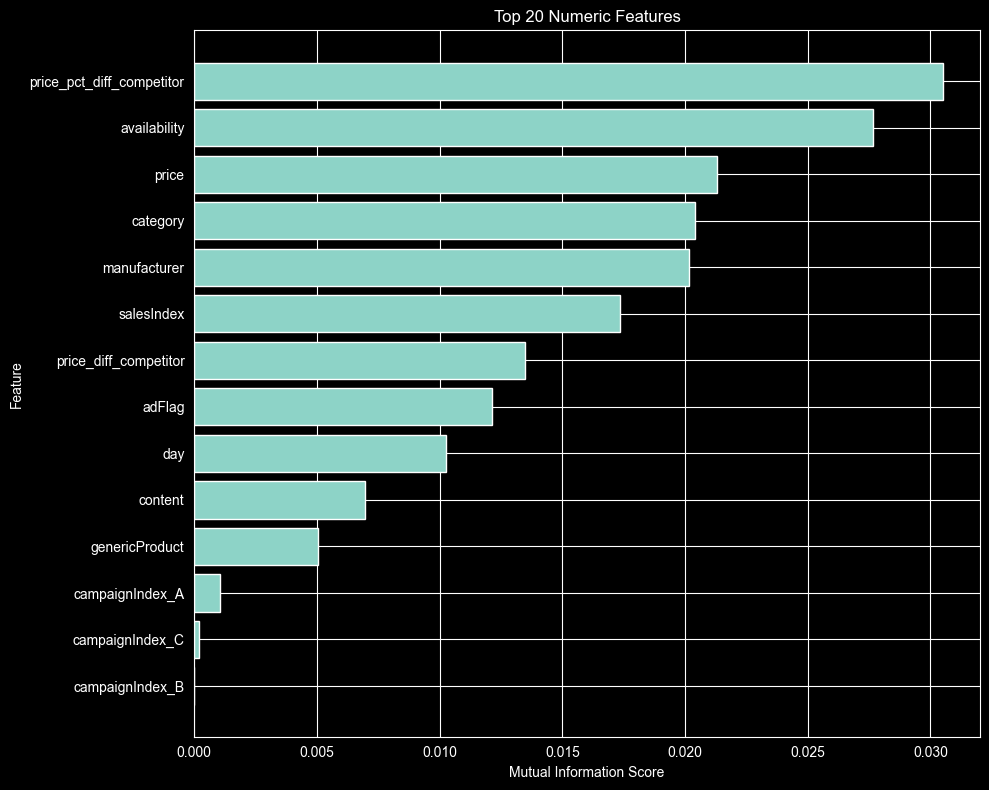

In [13]:
import matplotlib.pyplot as plt

plot_df = mi_df.head(20).sort_values("score")

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["score"])
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Top 20 Numeric Features")
plt.tight_layout()
plt.show()

## Bivariate selection

### Prepare numeric features for correlation analysis

In [6]:
# Build feature matrix and target
X = df.drop(columns=drop_cols, errors="ignore").copy()
y = df[target].copy()

# Keep only numeric features for correlation analysis
X_num = X.select_dtypes(include=["number"]).copy()

print(X_num.shape)
print(X_num.columns.tolist())

# Replace infinite values with NaN
X_num = X_num.replace([np.inf, -np.inf], np.nan)

# Fill missing numeric values temporarily for correlation analysis
X_num_filled = X_num.fillna(X_num.median())

print("Remaining missing values:", X_num_filled.isna().sum().sum())

(200000, 17)
['day', 'adFlag', 'availability', 'competitorPrice', 'price', 'manufacturer', 'content', 'genericProduct', 'salesIndex', 'category', 'rrp', 'campaignIndex_A', 'campaignIndex_B', 'campaignIndex_C', 'price_diff_competitor', 'price_ratio_competitor', 'price_pct_diff_competitor']
Remaining missing values: 0


### Compute Pearson correlation matrix

                                day    adFlag  availability  competitorPrice  \
day                        1.000000 -0.023937      0.016288         0.025001   
adFlag                    -0.023937  1.000000     -0.172356         0.004333   
availability               0.016288 -0.172356      1.000000         0.042848   
competitorPrice            0.025001  0.004333      0.042848         1.000000   
price                      0.023820  0.025675      0.048427         0.955358   
manufacturer               0.017517 -0.122879      0.090257         0.113171   
content                    0.015526 -0.069698     -0.015164         0.341829   
genericProduct            -0.021847  0.122598     -0.056702        -0.194072   
salesIndex                 0.010320 -0.296374      0.054251         0.160306   
category                  -0.001417  0.049370     -0.015229         0.075461   
rrp                        0.020069  0.063271      0.006475         0.965392   
campaignIndex_A           -0.064406  0.0

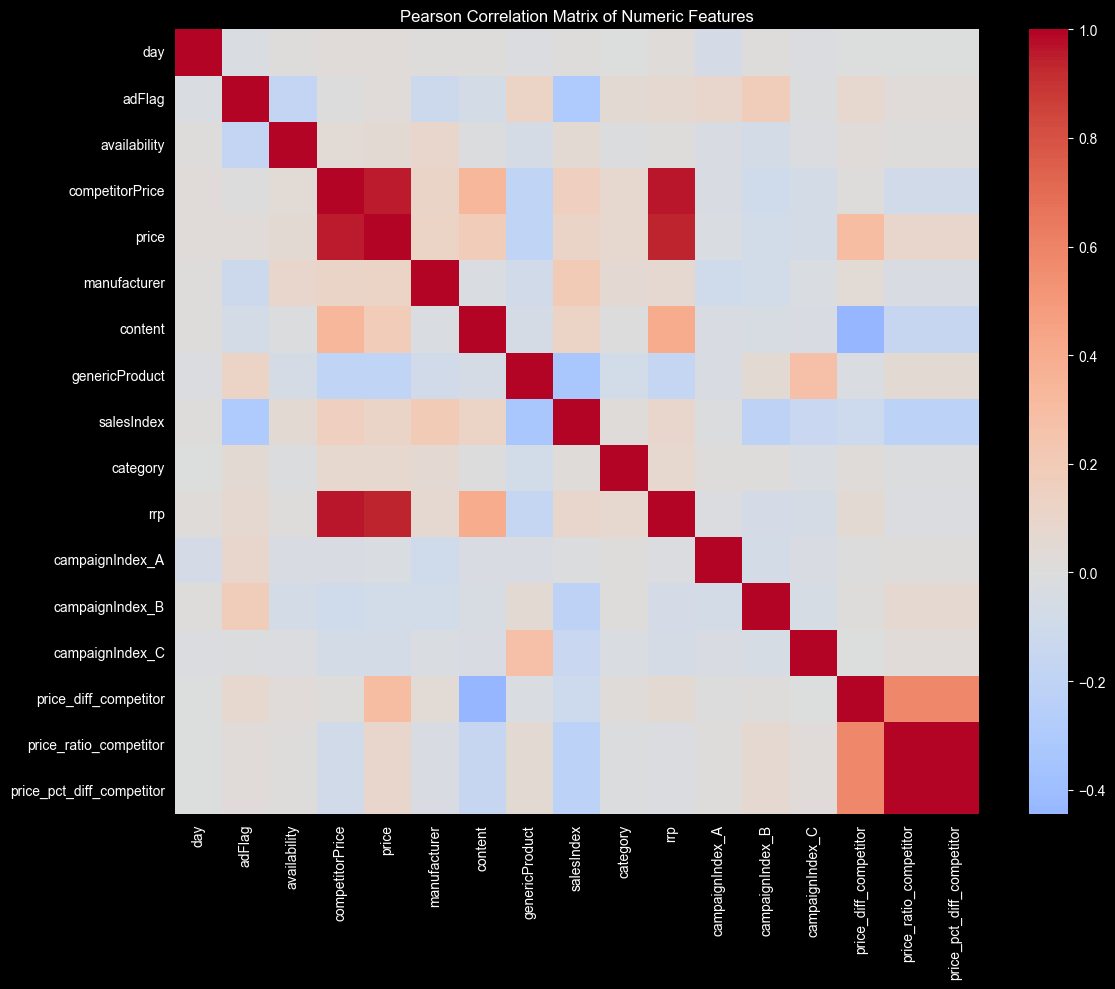

In [9]:
corr_matrix = X_num_filled.corr(method="pearson")
print(corr_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

### Extract highly correlated feature pairs

In [10]:
corr_abs = corr_matrix.abs()

upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

threshold = 0.8
high_corr_pairs = []

for col in upper_triangle.columns:
    for row in upper_triangle.index:
        corr_value = upper_triangle.loc[row, col]
        if pd.notna(corr_value) and corr_value > threshold:
            high_corr_pairs.append((row, col, corr_value))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "correlation"]
).sort_values("correlation", ascending=False)

high_corr_df

,feature_1,feature_2,correlation
3,price_ratio_competitor,price_pct_diff_competitor,0.999908
1,competitorPrice,rrp,0.965392
0,competitorPrice,price,0.955358
2,price,rrp,0.935518


These features are strongly correlated and might be redundant to use them all

## Split data
The top 10 numeric features were selected based on their mutual information ranking. These features were used to create the final input matrix X, which was then split into training and test sets using a stratified split. Stratification ensures that the proportion of purchased and non-purchased items remains similar in both subsets, making the evaluation more reliable.

In [14]:
from sklearn.model_selection import train_test_split

top_10_features = mi_df.head(10)["feature"].tolist()
X = X_num_filled[top_10_features].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(160000, 10) (40000, 10)
0.25585625 0.25585


### check if we have missing values
if 0 missing values we can proceed otherwise we need to fix it

In [15]:
print("Missing values in X_train before imputation:")
print(X_train.isna().sum().sort_values(ascending=False))

print("\nMissing values in X_test before imputation:")
print(X_test.isna().sum().sort_values(ascending=False))

Missing values in X_train before imputation:
price_pct_diff_competitor    0
availability                 0
price                        0
category                     0
manufacturer                 0
salesIndex                   0
price_diff_competitor        0
adFlag                       0
day                          0
content                      0
dtype: int64

Missing values in X_test before imputation:
price_pct_diff_competitor    0
availability                 0
price                        0
category                     0
manufacturer                 0
salesIndex                   0
price_diff_competitor        0
adFlag                       0
day                          0
content                      0
dtype: int64


## Training XGBoost
An XGBoost classifier was trained on the selected numeric features to predict whether a product would be purchased (order = 1). The model was configured with a set of initial hyperparameters and adjusted for class imbalance using scale_pos_weight, so that the minority class received more attention during training. After fitting the model on the training data, predictions and predicted probabilities were generated for the test set, and the model performance was evaluated using ROC-AUC, PR-AUC, the classification report, and the confusion matrix.

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("PR-AUC:", average_precision_score(y_test, y_pred_proba))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.6944893477048804
PR-AUC: 0.4146288608676567

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.65      0.73     29766
           1       0.38      0.64      0.48     10234

    accuracy                           0.64     40000
   macro avg       0.61      0.64      0.60     40000
weighted avg       0.72      0.64      0.67     40000


Confusion matrix:
[[19269 10497]
 [ 3729  6505]]


## Interpretation of XGBoost Results
The XGBoost model achieved a ROC-AUC of 0.679 and a PR-AUC of 0.401, indicating that it performs better than random guessing and is able to capture meaningful patterns related to purchase behavior. However, the performance is still moderate, which suggests that the selected numeric features alone are not sufficient for highly accurate prediction.

The classification report shows that the model performs noticeably better on the majority class (order = 0) than on the minority class (order = 1). For the purchase class, the model reached a precision of 0.37 and a recall of 0.62. This means that it was able to identify a relatively large share of actual purchases, but many of the predicted purchases were false positives.

This pattern is also visible in the confusion matrix. The model correctly identified 6,390 true purchases, but at the same time incorrectly predicted 10,896 non-purchases as purchases. In practical terms, the model is relatively sensitive to purchase cases, but its positive predictions are not very precise.

Overall, the model provides a reasonable first baseline and confirms that there is predictive signal in the dataset. At the same time, the results indicate that further improvement is needed, for example through additional feature engineering, better handling of categorical variables, or model tuning.

## Try again but with all features (top10, top15, all)

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
import pandas as pd

feature_sets = {
    "top_10": mi_df.head(10)["feature"].tolist(),
    "top_15": mi_df.head(15)["feature"].tolist(),
    "all_numeric": mi_df["feature"].tolist()
}

results = []

for name, features in feature_sets.items():
    X_current = X_num_filled[features].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X_current,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1)
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "feature_set": name,
        "n_features": len(features),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
        "pr_auc": average_precision_score(y_test, y_pred_proba),
        "precision_1": precision_score(y_test, y_pred),
        "recall_1": recall_score(y_test, y_pred),
        "f1_1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df

,feature_set,n_features,roc_auc,pr_auc,precision_1,recall_1,f1_1
2,all_numeric,17,0.704999,0.428479,0.385762,0.653793,0.485224
1,top_15,15,0.704650,0.428061,0.385800,0.653538,0.485184
0,top_10,10,0.689443,0.412500,0.372641,0.643489,0.471968


##Interpretation of Feature Set Comparison

The comparison of different feature subset sizes showed that the top 15 ranked numeric features produced the best overall performance. Compared with the top 10 feature model, the inclusion of additional variables improved ROC-AUC, PR-AUC, recall, and F1-score, indicating that the top 10 subset was too restrictive. Expanding further to all available numeric features did not lead to additional improvement, which suggests that the strongest predictive information was already captured within the top 15 features.